# Eksplorasi Data Campuran
Dalam dataset ini, setiap baris disebut sebagai Objek Data (sering juga disebut record atau sample). Objek data di sini adalah Aplikasi Mobile.

Setiap objek dijelaskan oleh beberapa Atribut (fitur). Mengacu pada materi Understanding Data, berikut adalah klasifikasi atribut dalam dataset ini:

| Nama Atribut     | Tipe Atribut         | Penjelasan                                                         |
|------------------|----------------------|--------------------------------------------------------------------|
| App              | Nominal              | Nama unik aplikasi (sebagai identifier).                          |
| Category         | Nominal              | Kategori tanpa urutan (HEALTH, TOOLS, dll).                       |
| Type             | Binary (Symmetric)   | Hanya ada dua nilai: Free atau Paid.                              |
| Content_Rating   | Ordinal              | Memiliki urutan logis (Everyone < Teen < Mature).                 |
| Rating           | Numeric (Interval)   | Nilai kontinu dengan rentang 1.0 - 5.0.                           |
| Price_$          | Numeric (Ratio)      | Nilai uang, di mana angka 0 benar-benar berarti gratis.           |

## Data Deskriptif
- Mean & Median: Jika nilai Mean (rata-rata) dan Median (50%) pada Rating berdekatan, maka data terdistribusi cukup normal.

- Five-Number Summary: Terdiri dari Nilai Min, Q1 (Kuartil 1), Median, Q3, dan Max. Ini berguna untuk mendeteksi adanya pencilan (outliers) pada harga aplikasi.

## Eksplorasi Data (Data Exploration)

In [1]:
import pandas as pd

df = pd.read_csv('google_play_store_apps_famous.csv')
# Cek Missing Values
print("Cek Data Kosong:")
print(df.isnull().sum())

# Cek Variasi Kategori (Atribut Nominal)
print("\nJumlah Aplikasi unik per Kategori:")
print(df['Category'].value_counts().head(10))

# Cek Distribusi Tipe (Atribut Binary)
print("\nPerbandingan Free vs Paid:")
print(df['Type'].value_counts(normalize=True) * 100)

Cek Data Kosong:
App                0
Category           0
Rating             0
Reviews            0
Size_MB            0
Installs           0
Type               0
Price_$            0
Content_Rating     0
Genres             0
Last_Updated       0
Android_Version    0
dtype: int64

Jumlah Aplikasi unik per Kategori:
Category
GAME             158
EDUCATION        144
TOOLS            142
HEALTH           136
ENTERTAINMENT    134
FINANCE          128
PRODUCTIVITY     122
LIFESTYLE        118
BUSINESS         118
Name: count, dtype: int64

Perbandingan Free vs Paid:
Type
Free    84.75
Paid    15.25
Name: proportion, dtype: float64


## Visualisasi Data
Visualisasi memberikan pandangan pertama terhadap pola data, clusters, atau outliers sebelum kita menghitung jarak antar data.

1. Histogram (Distribusi Rating)
Digunakan untuk melihat frekuensi kemunculan nilai pada atribut numerik.

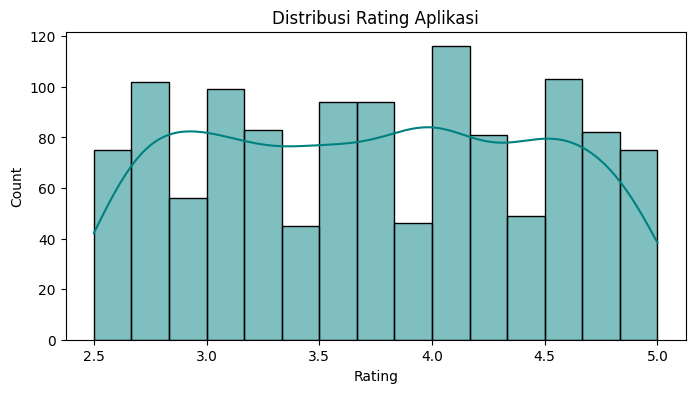

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df['Rating'], bins=15, kde=True, color='teal')
plt.title('Distribusi Rating Aplikasi')
plt.show()

## Box Plot (Deteksi Outlier Harga)
Sangat efektif untuk melihat sebaran data berdasarkan kuartil dan melihat apakah ada aplikasi yang harganya jauh di atas rata-rata.

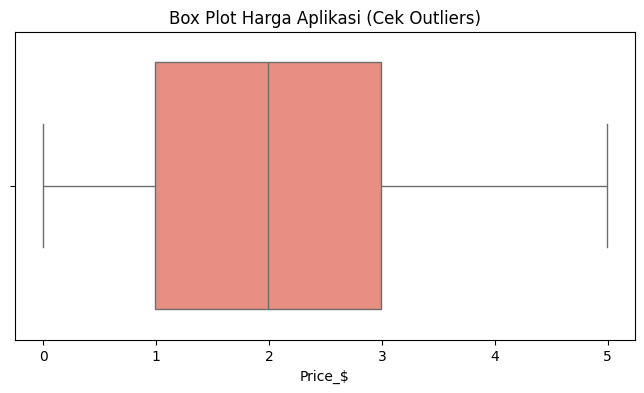

In [3]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Price_$'], color='salmon')
plt.title('Box Plot Harga Aplikasi (Cek Outliers)')
plt.show()

## Scatter Plot (Korelasi Rating vs Reviews)
Setiap pasang nilai diperlakukan sebagai koordinat untuk melihat apakah ada hubungan (positif, negatif, atau tidak berkorelasi) antar dua atribut.

![scatterplot.png](scatterplot.png)